# 2b – Blick in den Index: DB-Rohdaten & Retrieval sichtbar machen

Dieses Notebook **verändert nichts** – es öffnet den fertigen Index nur lesend und macht
zwei Dinge sichtbar, die sonst verborgen bleiben:

1. **Wie die Vektor-DB aussieht** – IDs, Metadaten, Vektoren, Klartext
2. **Was `similarity_search` tut** – dieselbe Suche, aber mit Distanz-Score pro Treffer

> **Voraussetzung:** Notebook 1 lief, `./chroma_db` existiert. Ein laufender Kernel von
> Notebook 2 ist *nicht* nötig – hier wird alles selbst geladen.

## Minimal-Konfiguration

Nur das, was zum Lesen des Index gebraucht wird. Das Embedding-Modell steht hier auf
`text-embedding-bge-m3` – **passend zum Manifest**, mit dem der Index gebaut wurde.

In [1]:
DB_DIR          = "./chroma_db"
COLLECTION_NAME = "langchain"
LM_STUDIO_URL   = "http://localhost:1234/v1"
EMBEDDING_MODEL = "text-embedding-multilingual-e5-large-instruct"   # muss dem Manifest entsprechen!
TOP_K           = 10

## Embedding-Modell & Vektordatenbank laden

In [2]:
import os
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


class E5OpenAIEmbeddings(OpenAIEmbeddings):
    """Gleicher Wrapper wie in Notebook 1 – muss identisch sein, damit die
    Query-Vektoren genauso entstehen wie die Dokument-Vektoren im Index."""

    def embed_documents(self, texts):
        return super().embed_documents(["passage: " + t for t in texts])

    def embed_query(self, text):
        return super().embed_query("query: " + text)


embeddings = E5OpenAIEmbeddings(
    model=EMBEDDING_MODEL,
    api_key="lm-studio",
    base_url=LM_STUDIO_URL,
    check_embedding_ctx_length=False,
)

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    persist_directory=DB_DIR,
    embedding_function=embeddings,
)

print(f"✅ Vektordatenbank geladen – {vectorstore._collection.count()} Chunks verfügbar.")

c:\Users\natal\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


✅ Vektordatenbank geladen – 5953 Chunks verfügbar.


## 1 – Rohblick in die Datenbank

`col.get(...)` holt Datensätze **ohne Suche** direkt aus der Collection. So sieht ein
gespeicherter Chunk wirklich aus: eine ID, die Metadaten, der Vektor (hier bge-m3 → 1024
Dimensionen, davon die ersten fünf) und der Klartext.

In [3]:
col = vectorstore._collection
print("Anzahl Chunks:", col.count())

sample = col.get(limit=5, include=["documents", "metadatas", "embeddings"])

for i in range(len(sample["ids"])):
    vec = sample["embeddings"][i]
    print("\nID:       ", sample["ids"][i])
    print("Metadaten:", sample["metadatas"][i])
    print("Vektor:   ", len(vec), "Dim →", [round(x, 3) for x in vec[:5]], "...")
    print("Text:     ", repr(sample["documents"][i]))

Anzahl Chunks: 5953

ID:        3c4d2ed9-4719-43eb-84a5-9c8cd9c83687
Metadaten: {'creationdate': '2024-06-04T16:10:15+02:00', 'author': 'Bundesministerium für Arbeit und Soziales (BMAS)', 'source': './documents\\20240604-Shortpaper_Standards-fuer-KI.pdf', 'file_path': './documents\\20240604-Shortpaper_Standards-fuer-KI.pdf', 'title': 'Standards für KI: Warum der AI Act nur der Anfang der europäischen KI-Regulierung ist', 'subject': '', 'creationDate': "D:20240604161015+02'00'", 'keywords': '', 'total_pages': 6, 'format': 'PDF 1.6', 'moddate': '2024-06-06T09:16:15+02:00', 'creator': 'Acrobat PDFMaker 24 für Word', 'trapped': '', 'page': 0, 'producer': 'Adobe PDF Library 24.2.23', 'modDate': "D:20240606091615+02'00'"}
Vektor:    1024 Dim → [np.float64(0.021), np.float64(-0.006), np.float64(0.003), np.float64(-0.029), np.float64(0.039)] ...
Text:      '#1 – Shortpaper Standards für KI    1 \n \nStandards für KI: Warum der AI Act nur der Anfang der \neuropäischen KI-Regulierung ist \n#1 

### Und auf der Festplatte?

Die Collection ist keine einzelne Datei. In `chroma.sqlite3` liegen IDs, Text und
Metadaten (mit `sqlite3` oder „DB Browser for SQLite“ lesbar); die eigentlichen Vektoren
stecken als binärer HNSW-Index im UUID-Unterordner – bewusst nicht menschenlesbar.

In [4]:
for root, _, files in os.walk(DB_DIR):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"{os.path.getsize(p) // 1024:>7} KB  {p}")

  61840 KB  ./chroma_db\chroma.sqlite3
  22590 KB  ./chroma_db\c7a9c237-2da1-438f-97d9-caf23ebcf28f\data_level0.bin
      0 KB  ./chroma_db\c7a9c237-2da1-438f-97d9-caf23ebcf28f\header.bin
    490 KB  ./chroma_db\c7a9c237-2da1-438f-97d9-caf23ebcf28f\index_metadata.pickle
     21 KB  ./chroma_db\c7a9c237-2da1-438f-97d9-caf23ebcf28f\length.bin
     45 KB  ./chroma_db\c7a9c237-2da1-438f-97d9-caf23ebcf28f\link_lists.bin


## 2 – In `similarity_search` hineinschauen

`similarity_search` liefert nur die Chunks. `similarity_search_with_score` liefert
zusätzlich die **Distanz** – und die macht sichtbar, *warum* gerade diese Treffer kommen.

> Der Wert ist eine Distanz, **kein** Prozent: **kleiner = ähnlicher**. Achte auf den
> Abstand zwischen Platz 1 und Platz 10 – er zeigt, wie deutlich der Index sich „sicher“ ist.

In [5]:
frage = "Was ist eine Hochrisiko-Anwendung" #"Was verbietet der AI Act?"

# Stabile Index-Liste (0 … 5960)
all_ids    = col.get(include=[])["ids"]
idx_von_id = {cid: i for i, cid in enumerate(all_ids)}

# Rohe Chroma-Suche: liefert zusätzlich die IDs (die similarity_search verschluckt)
qv  = embeddings.embed_query(frage)
res = col.query(query_embeddings=[qv], n_results=TOP_K,
                include=["documents", "metadatas", "distances"])

print(f"Frage: {frage}\n")
print(f"{'Idx':>5}  {'Distanz':>8}  {'Quelle':<45} {'Seite':>5}  Text")
print("-" * 105)
for cid, doc, meta, dist in zip(res["ids"][0], res["documents"][0],
                                res["metadatas"][0], res["distances"][0]):
    quelle = os.path.basename(meta.get("source", "?"))
    seite  = meta.get("page", 0) + 1
    print(f"{idx_von_id[cid]:>5}  {dist:8.4f}  {quelle[:45]:<45} {seite:>5}  {repr(doc[:100])}...")

Frage: Was ist eine Hochrisiko-Anwendung

  Idx   Distanz  Quelle                                        Seite  Text
---------------------------------------------------------------------------------------------------------
 1897    0.2474  Künstliche Intelligenz im Rahmen des AI Acts     18  '18 \n \n2.7.2.  Hochrisiko-KI-Systeme \nHochrisiko-KI-Systeme stellen die zweite und umfangreichste Ris'...
 3161    0.2509  OJ_L_202401689_DE_TXT.pdf                        69  'diesem Zweck führen die Betreiber eine Abschätzung durch, die Folgendes umfasst:\na) eine Beschreibun'...
 3007    0.2578  OJ_L_202401689_DE_TXT.pdf                        56  'b) die Abschätzung und Bewertung der Risiken, die entstehen können, wenn das Hochrisiko-KI-System en'...
  521    0.2602  Guidelines_on_prohibited_artificial_intellige    11  'es weiterhin ein Hochrisiko-KI-System gemäß Artikel 6 bleibt; c) wenn sie die Zweckbestimmung eines '...
 2515    0.2619  OJ_L_202401689_DE_TXT.pdf                        26 

### Ähnlichkeit der Chunks visualisieren

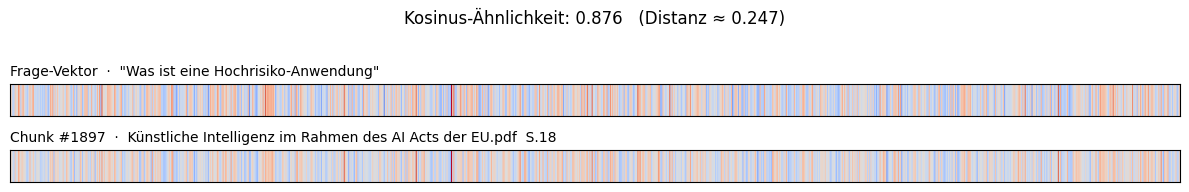


Chunk-Text:
18 
 
2.7.2.  Hochrisiko-KI-Systeme 
Hochrisiko-KI-Systeme stellen die zweite und umfangreichste Risikokategorie dar, die somit 
das Herzstück des AI Acts bilden. Sie umfassen Anwendungen, deren Verwendung erhebliche 
Auswirkungen auf die Gesundheit, Sicherheit oder Grundrechte von Menschen haben kann, 
ohne dass ein absolutes Verbot notwendig wäre. Diese Systeme dürfen grundsätzlich in 
Verkehr gebracht und genutzt werden, unterliegen aber besonders strengen gesetzlichen 
Anforderungen.67 


In [9]:
import os, numpy as np
import matplotlib.pyplot as plt

# ▼ Welchen Chunk ansehen? Index aus der Tabelle oben (0 … 5960)
CHUNK_INDEX = 1897
#frage       =  "Was verbietet der AI Act?"

all_ids = col.get(include=[])["ids"]
chunk   = col.get(ids=[all_ids[CHUNK_INDEX]],
                  include=["embeddings", "documents", "metadatas"])

chunk_vec = np.array(chunk["embeddings"][0])          # aus der DB → "passage:"-Raum
frage_vec = np.array(embeddings.embed_query(frage))   # frisch    → "query:"-Raum

cos  = float(frage_vec @ chunk_vec /
             (np.linalg.norm(frage_vec) * np.linalg.norm(chunk_vec)))
dist = 2 - 2 * cos                                    # ≈ Chroma-Distanz (quadr. L2)

meta   = chunk["metadatas"][0]
quelle = os.path.basename(meta.get("source", "?"))
seite  = meta.get("page", 0) + 1

def strich_code(ax, vec, titel):
    lim = np.abs(vec).max()
    ax.imshow(vec.reshape(1, -1), aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)
    ax.set_title(titel, fontsize=10, loc="left")
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 1, figsize=(12, 1.8))
strich_code(axes[0], frage_vec, f'Frage-Vektor  ·  "{frage}"')
strich_code(axes[1], chunk_vec, f"Chunk #{CHUNK_INDEX}  ·  {quelle}  S.{seite}")
fig.suptitle(f"Kosinus-Ähnlichkeit: {cos:.3f}   (Distanz ≈ {dist:.3f})", fontsize=12, y=1.04)
fig.tight_layout(); plt.show()

print(f"\nChunk-Text:\n{chunk['documents'][0]} ")

### Den Query-Vektor selbst ansehen

Genau das passiert im Hintergrund vor der Suche: die Frage wird zum Vektor. Der Wrapper
stellt automatisch `query: ` voran (deshalb taucht es im Ergebnis nicht auf).

In [7]:
qv = embeddings.embed_query(frage)
print("Query-Vektor:", len(qv), "Dimensionen")
print("Erste zehn Werte:", [round(x, 3) for x in qv[:10]])

Query-Vektor: 1024 Dimensionen
Erste zehn Werte: [0.015, 0.015, -0.026, -0.025, 0.025, 0.007, 0.007, 0.065, 0.039, -0.028]


### Export für die Webseite

In [ ]:
import os, json, random
from collections import defaultdict

random.seed(42)            # reproduzierbar – die Demo bleibt über Läufe stabil
PRO_DOKUMENT  = 60         # Chunks je Dokument (geschichtete Stichprobe)
SOURCE_FILTER = ""         # "" = alle Dokumente; sonst Teilstring des Dateinamens
NACHKOMMA     = 4

all_ids    = col.get(include=[])["ids"]
idx_von_id = {cid: i for i, cid in enumerate(all_ids)}
meta_all   = col.get(include=["metadatas"])

# 1) Chunk-IDs nach Dokument gruppieren
nach_doc = defaultdict(list)
for cid, m in zip(meta_all["ids"], meta_all["metadatas"]):
    if SOURCE_FILTER in m.get("source", ""):
        nach_doc[m["source"]].append(cid)

# 2) aus jedem Dokument gleich viele ziehen (oder alle, wenn weniger)
gewaehlt = []
for quelle, ids in sorted(nach_doc.items()):
    stichprobe = random.sample(ids, min(PRO_DOKUMENT, len(ids)))
    gewaehlt.extend(stichprobe)
    print(f"  {os.path.basename(quelle):40s} {len(stichprobe):4d} / {len(ids)}")

# 3) nur für die Auswahl die Vektoren laden
daten = col.get(ids=gewaehlt, include=["embeddings", "documents", "metadatas"])

chunks = []
for cid, vec, doc, m in zip(daten["ids"], daten["embeddings"],
                            daten["documents"], daten["metadatas"]):
    chunks.append({
        "db_index": idx_von_id[cid],
        "quelle":   os.path.basename(m.get("source", "?")),
        "seite":    m.get("page", 0) + 1,
        "text":     doc,
        "vec":      [round(float(x), NACHKOMMA) for x in vec],
    })

export = {"embedding_model": EMBEDDING_MODEL, "query_prefix": "query: ",
          "dims": len(chunks[0]["vec"]), "anzahl": len(chunks), "chunks": chunks}

with open("demo_daten.json", "w", encoding="utf-8") as f:
    json.dump(export, f, ensure_ascii=False)

print(f"\n✅ {len(chunks)} Chunks aus {len(nach_doc)} Dokumenten "
      f"→ demo_daten.json ({os.path.getsize('demo_daten.json')/1024/1024:.2f} MB)")

  20240604-Shortpaper_Standards-fuer-KI.pdf   47 / 47
  2104.05314v2.pdf                           60 / 159
  EU-6-001-25-pdf.pdf                        60 / 221
  Guidelines_on_prohibited_artificial_intelligence_practices_established_by_Regulation_EU_20241689_AI_Act_German.PDF   60 / 1361
  Künstliche Intelligenz im Rahmen des AI Acts der EU.pdf   60 / 255
  OJ_L_202401689_DE_TXT.pdf                  60 / 1898
  Regulierung von KI _ Künstliche Intelligenz _ bpb.de.pdf   60 / 76
  gutachten-datenethikkommission.pdf         60 / 1936

✅ 467 Chunks aus 8 Dokumenten → demo_daten.json (4.09 MB)
